In [1]:
from typing import List, TypedDict, Literal
from pydantic import BaseModel
import re


from langchain_classic.retrievers import (ContextualCompressionRetriever,
                EnsembleRetriever, BM25Retriever, ParentDocumentRetriever)

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.document_compressors.flashrank_rerank import FlashrankRerank
from langchain_community.vectorstores import FAISS
from langchain_community.tools.tavily_search import TavilySearchResults

from langchain_google_genai.chat_models import ChatGoogleGenerativeAI
from langchain_google_genai.embeddings import GoogleGenerativeAIEmbeddings

from langchain_ollama import OllamaEmbeddings, OllamaLLM, ChatOllama

from langchain_text_splitters import RecursiveCharacterTextSplitter

from langchain_core.documents import Document
from langchain_core.stores import InMemoryStore
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import PydanticOutputParser

from langgraph.graph import StateGraph, START, END

import os
from dotenv import load_dotenv

load_dotenv()

True

In [ ]:
LLM_MODEL = os.getenv("LLM_MODEL")
EMBEDDING_MODEL = os.getenv("EMBEDDING_MODEL")
PROVIDER = os.getenv("PROVIDER")

In [40]:
docs = (
    PyPDFLoader("./book1.pdf").load()
    # + PyPDFLoader("./book2.pdf").load()
    # + PyPDFLoader("./book3.pdf").load()
)

In [41]:
docs = docs[100:200]

In [42]:
type(docs), len(docs)

(list, 100)

In [43]:
# To handle for unicode errors
for d in docs :
    d.page_content = d.page_content.encode("utf-8", "ignore").decode("utf-8", "ignore")

In [44]:
child_splitter = RecursiveCharacterTextSplitter(chunk_size = 400, chunk_overlap = 20)
parent_splitter = RecursiveCharacterTextSplitter(chunk_size = 2000, chunk_overlap = 200)

In [45]:
bm25_chunks = parent_splitter.split_documents(docs)

len(bm25_chunks)

163

In [ ]:
if PROVIDER == "google"
    # Google embeddings
    embeddings = GoogleGenerativeAIEmbeddings(model = EMBEDDING_MODEL)
else :
    # Small local via ollama nomic-embed-text
    embeddings = OllamaEmbeddings(model = EMBEDDING_MODEL)

store = InMemoryStore()

# We initialize FAISS with a dummy text just to set the dimensions, then empty it
vector_store = FAISS.from_texts(["init"], embeddings)

INFO:httpx:HTTP Request: POST http://127.0.0.1:11434/api/embed "HTTP/1.1 200 OK"


In [47]:
bm25_retriever = BM25Retriever.from_documents(bm25_chunks)
bm25_retriever.k = 5

compressor = FlashrankRerank(model = "ms-marco-MiniLM-L-12-v2", top_n = 5)

pdf_retriever = ParentDocumentRetriever(
    vectorstore = vector_store,
    docstore = store,
    child_splitter = child_splitter,
    parent_splitter = parent_splitter,
    search_kwargs = {
        "k" : 15
    }
)

# This step actually splits the 'docs' into parents/children and indexes them
pdf_retriever.add_documents(docs)

ensemble_retriever = EnsembleRetriever(
    retrievers = [bm25_retriever, pdf_retriever],
    weights = [0.3, 0.7]
)

retriever = ContextualCompressionRetriever(
    base_compressor = compressor,
    base_retriever = ensemble_retriever
)

INFO:httpx:HTTP Request: POST http://127.0.0.1:11434/api/embed "HTTP/1.1 200 OK"


In [ ]:
if PROVIDER == "google" :
    llm = ChatGoogleGenerativeAI(
        model = LLM_MODEL,
        temperature = 0
    )
else :
    llm = ChatOllama(
        model = LLM_MODEL,
        temperature = 0
    )

# Simple RAG

In [26]:
class State(TypedDict) :
    question : str
    docs : List[Document]
    answer : str

In [27]:
def retrieve(state : State) -> dict :
    q = state["question"]
    return {
        "docs" : retriever.invoke(q)
        }

In [28]:
prompt = ChatPromptTemplate.from_messages(
    [
        ("system", "Answer only from the context. If not in context say you don't know."),
        ("human", "Question : {question}\n\nContext : {context}"),
    ]
)

In [32]:
def generate(state : State) -> dict :
    context = "\n\n".join(d.page_content for d in state["docs"])
    out = (prompt | llm).invoke({
        "question" : state["question"],
        "context" : context
    })
    return {
        "answer" : out
    }

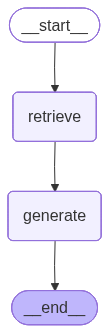

In [33]:
g = StateGraph(State)

g.add_node("retrieve", retrieve)
g.add_node("generate", generate)

g.add_edge(START, "retrieve")
g.add_edge("retrieve", "generate")
g.add_edge("generate", END)

app = g.compile()

app

In [37]:
res = app.invoke({
    "question" : "What is the essence of SHA256 in Cyber Security?",
    "docs" : [],
    "answer" : ""
})

In [38]:
print(res["answer"])

The essence of SHA256 in cybersecurity is its role as a cryptographic hash function, which ensures data integrity and security by producing unique fixed-size hash values from input data (like passwords or files). These hashes are used to detect any changes or tampering with the original data.

However, based on your provided context alone, I cannot provide specific details about SHA256's role in cybersecurity as it is not included within this text snippet. The given equations and discussions seem unrelated to cryptographic hash functions like SHA-256 or their applications in cyber security from the presented information.

If you can provide more context related to SHA256, I would be able to give a better answer regarding its essence in Cyber Security.


# CRAG

In [51]:
UPPER_THRESHOLD = 0.7
LOWER_THRESHOLD = 0.3

In [52]:
class State(TypedDict) :
    question : str
    hypothetical_answer : str

    docs : List[Document]
    good_docs : List[Document]
    web_docs : List[Document]
    
    verdict : str
    reason : str
    
    strips : List[str]
    kept_strips : List[str]
    
    refined_context : str

    web_query : str
    
    answer : str

## Retrieve

In [79]:
hypothetical_answer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a professional who gives answers of questions with unknown context.\n"
            "Please write a scientific paper passage to answer the question.\n",
        ),
        ("human", "Question: {question}"),
    ]
)

hypothetical_answer_chain = hypothetical_answer_prompt | llm

In [80]:
def retrieve(state : State) -> dict :
    print("RETRIEVE")
    q = state["question"]

    hypothetical_answer : str = hypothetical_answer_chain.invoke({
        "question" : q
    })

    return {
        "hypothetical_answer" : hypothetical_answer,
        "docs" : retriever.invoke(hypothetical_answer)
        }

## Evaluator

In [81]:
class Score(BaseModel) :
    score : float
    reason : str

In [82]:
score_parser = PydanticOutputParser(pydantic_object = Score)

In [83]:
eval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict retrieval evaluator for RAG.\n"
            "You will be given ONE retrieved chunk and a question.\n"
            "Return a relevance score in [0.0, 1.0].\n"
            "- 1.0: chunk alone is sufficient to answer fully/mostly\n"
            "- 0.0: chunk is irrelevant\n"
            "Be conservative with high scores.\n"
            "Also return a short reason.\n"
            "Output JSON only :"
            "{format_instructions}",
        ),
        ("human", "Question: {question}\n\nChunk:\n{chunk}"),
    ]
)

In [84]:
eval_chain = eval_prompt | llm | score_parser

In [85]:
def eval(state : State) -> dict :
    print("EVAL")
    q = state["question"]

    scores : List[float] = []
    reasons : List[str] = []
    good : List[Document] = []

    for d in state["docs"] :
        out : Score = eval_chain.invoke({
            "question" : q,
            "chunk" : d.page_content,
            "format_instructions" : score_parser.get_format_instructions()
        })
        scores.append(out.score)
        reasons.append(out.reason)

        if out.score > LOWER_THRESHOLD :
            good.append(d)
    
    if any(score > UPPER_THRESHOLD for score in scores) :
        return {
            "good_docs" : good,
            "verdict" : "CORRECT",
            "reason" : f"One or more docs scored greater than {UPPER_THRESHOLD}"
        }
    
    if len(scores) > 0 and all(score < LOWER_THRESHOLD for score in scores) :
        return {
            "good_docs" : [],
            "verdict" : "INCORRECT",
            "reason" : f"All chunks scored less than {LOWER_THRESHOLD}"
        }
    
    return {
        "good_docs" : good,
        "verdict" : "AMBIGUOUS",
        "reason" : f"No chunk scored greater than {UPPER_THRESHOLD}, but not all were less than {LOWER_THRESHOLD}"
    }

## Refine

In [91]:
def decompose_to_sentences(text : str) -> List[str] :
    print("DECOMPOSE")
    text = re.sub(r"\s+", " ", text).strip()
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return [s.strip() for s in sentences if len(s.strip()) > 20]

In [92]:
class KeepOrDrop(BaseModel) :
    keep : bool

In [93]:
filter_parser = PydanticOutputParser(pydantic_object = KeepOrDrop)

In [94]:
filter_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict relevance filter.\n"
            "Return keep = true only if the sentence directly helps answer the question.\n"
            "Use ONLY the sentence. Output JSON only :"
            "{format_instructions}"
        ),
        ("human", "Question: {question}\n\nSentence:\n{sentence}"),
    ]
)

filter_chain = filter_prompt | llm | filter_parser

In [95]:
def refine(state : State) -> dict :
    print("REFINE")
    q = state["question"]

    if state.get("verdict") == "CORRECT" :
        context_docs = state["good_docs"]
    elif state.get("verdict") == "INCORRECT" :
        context_docs = state["web_docs"]
    else :
        context_docs = state["good_docs"] + state["web_docs"]

    context = "\n\n".join(d.page_content for d in context_docs).strip()

    strips = decompose_to_sentences(context)

    kept : List[str] = []

    for s in strips :
        try :
            keep = filter_chain.invoke({
                "question" : q,
                "sentence" : s,
                "format_instructions" : filter_parser.get_format_instructions()
                }).keep
        except Exception as e :
            print("ERROR")
            print(f"QUESTION -> {q}")
            print(f"SENTENCE -> {s}")
            print(f"ANSWER -> {(filter_prompt | llm).invoke({'question' : q, 'sentence' : s})}")
            print(f"\n\n{e}")
            raise ValueError(e.__str__())
        if keep :
            kept.append(s)
    
    refined_context = "\n".join(kept).strip()

    return {
        "strips" : strips,
        "kept_strips" : kept,
        "refined_context" : refined_context,
    }

## Research

In [96]:
class WebQuery(BaseModel) :
    query : str

In [97]:
rewrite_parser = PydanticOutputParser(pydantic_object = WebQuery)

In [98]:
rewrite_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Rewrite the user question into a web search query composed of keywords.\n"
            "Rules:\n"
            "- Keep it short (6–14 words).\n"
            "- If the question implies recency (e.g., recent/latest/last week/last month), add a constraint like (last 30 days).\n"
            "- Do NOT answer the question.\n"
            "- Return JSON :"
            "{format_instructions}",
        ),
        ("human", "Question: {question}"),
    ]
)

In [99]:
rewrite_chain = rewrite_prompt | llm | rewrite_parser

In [100]:
def rewrite(state : State) -> dict :
    print("REWRITE")
    out = rewrite_chain.invoke({
        "question" : state["question"],
        "format_instructions" : rewrite_parser.get_format_instructions()
    })
    return {
        "web_query" : out.query
    }

In [101]:
tavily = TavilySearchResults(max_results = 5)

In [102]:
def research(state : State) -> dict :
    print("RESEARCH")
    q = state.get("web_query") or state["question"]

    results : dict = tavily.invoke({
        "query" : q
    })

    web_docs = []

    for r in results or [] :
        title = r.get("title", "")
        url = r.get("url", "")
        content = r.get("content", "") or r.get("snippet", "")

        text = f"TITLE : {title}\nURL : {url}\nCONTENT : {content}"

        web_docs.append(Document(page_content = text, metadata = {
            "url" : url,
            "title" : title
        }))
    
    return {
        "web_docs" : web_docs
    }

## Generate

In [104]:
answer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful ML tutor. Answer ONLY using the provided refined bullets.\n"
            "If the bullets are empty or insufficient, say: 'I don't know based on the provided books.'",
        ),
        ("human", "Question: {question}\n\nRefined context:\n{refined_context}"),
    ]
)

In [105]:
def generate(state : State) -> dict :
    print("GENERATE")
    out = (answer_prompt | llm).invoke({
        "question" : state["question"],
        "refined_context" : state["refined_context"]
    })
    return {
        "answer" : out
    }

## Others

In [103]:
def route_after_eval(state : State) -> str :
    if state["verdict"] == "CORRECT" :
        return "refine"
    else :
        return "rewrite"

## Graph

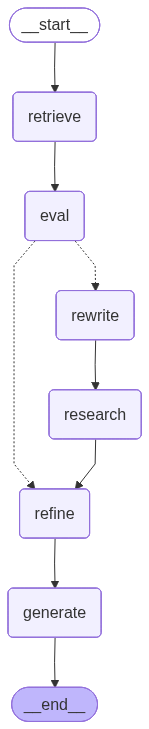

In [77]:
g = StateGraph(State)

g.add_node("retrieve", retrieve)
g.add_node("eval", eval)
g.add_node("rewrite", rewrite)
g.add_node("research", research)
g.add_node("refine", refine)
g.add_node("generate", generate)

g.add_edge(START, "retrieve")
g.add_edge("retrieve", "eval")

g.add_conditional_edges(
    "eval",
    route_after_eval,
    {
        "refine" : "refine",
        "rewrite" : "rewrite",
    }
)

g.add_edge("rewrite", "research")
g.add_edge("research", "refine")
g.add_edge("refine", "generate")
g.add_edge("generate", END)

app = g.compile()

app

In [78]:
res = app.invoke({
    "question" : "Compare classic neural networks with some recent new architectures.",
    "docs" : [],
    "good_docs": [],
    "web_docs": [],
    "verdict": "",
    "reason": "",
    "strips" : [],
    "kept_strips" : [],
    "refined_context" : "",
    "web_query" : "",
    "answer" : ""
})

INFO:httpx:HTTP Request: POST http://127.0.0.1:11434/api/generate "HTTP/1.1 200 OK"


KeyboardInterrupt: 

In [ ]:
print("VERDICT -> ", res["verdict"])
print("QUERY -> ", res["web_query"])
print("\nOUTPUT -> \n", res["answer"])

VERDICT ->  INCORRECT
QUERY ->  recent ai news last week

OUTPUT -> 
 Based on the provided context:

- Anthropic released Super Bowl ads portraying AI chatbots inserting intrusive sponsored content into conversations, positioning Claude as an ad-free alternative. OpenAI CEO Sam Altman rejected claims that ads would influence responses in these advertisements. The exchange highlighted the growing rivalry between Anthropic and OpenAI as both companies seek enterprise growth paths and potential IPOs.
  
- Software stocks experienced a significant slide following investor concerns about AI agents disrupting application providers, particularly after news of new Claude plug-ins extending large language models into workflows like legal, sales, marketing, and data analysis emerged. This selloff reflects the broader industry's anxiety over how LLMs might affect traditional software pricing power and revenue streams as they move deeper into application layers.
  
- Barclays is investing in AI t

In [142]:
res.keys()

dict_keys(['question', 'docs', 'good_docs', 'web_docs', 'verdict', 'reason', 'strips', 'kept_strips', 'refined_context', 'answer'])

In [143]:
res["refined_context"]

'TITLE : AI Update, January 30, 2026: AI News and Views From the Past Week URL : https://www.marketingprofs.com/opinions/2026/54252/ai-update-january-30-2026-ai-news-and-views-from-the-past-week CONTENT : Yahoo launches Scout, an AI answer engine built on user data and Web grounding.\nYahoo has debuted Scout, an AI-powered answer engine in US beta designed to convert queries into direct answers across tasks like shopping comparisons, stock analysis, weather planning, and fact checking.\n[...] Open-source personal assistant Clawdbot goes viral, then rebrands to Moltbot.\n[...] Congress proposes subpoena rights for AI-trained content.\nThe bipartisan bill requires AI developers to disclose training materials upon request, creating a new legal mechanism for transparency.\nThe proposal arrives amid escalating lawsuits and settlements involving AI training data and could materially affect how models are built and documented.\nTITLE : The latest AI news we announced in January - Google Blog 

In [144]:
res["verdict"]

'INCORRECT'

In [145]:
len(res["good_docs"])

0

In [146]:
len(res["web_docs"])

5